In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import sparse as sp

def TBU_SNM(p, phi1, phi2, omega=0, tau=0):
    """
    TBU bidireccional usando las ecuaciones de Capmany mapeadas a SNM.
    Incluye sensibilidad a la frecuencia (omega) y retardo (tau).
    """
    # Coeficientes de los acopladores
    c_a, s_a = np.sqrt(1 - p['K_a']), np.sqrt(p['K_a'])
    c_b, s_b = np.sqrt(1 - p['K_b']), np.sqrt(p['K_b'])
    
    # El multiplicador incluye la pérdida y la fase de propagación global
    multiplicador = np.sqrt(1-p['gamma_a'])*np.sqrt(1-p['gamma_b'])*np.exp(-1j*omega*tau)
    
    # Fases efectivas (programada + frecuencia)
    theta1 = phi1 + omega * tau
    theta2 = phi2 + omega * tau

    # Coeficientes de la matriz de transferencia H 
    m11 = c_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - s_a*s_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m12 = -1j*s_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_b*c_a*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m21 = -1j*s_b*c_a*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m22 = c_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2) - s_a*s_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1)

    # Matriz S local de 4x4 (mapea 4 nodos de entrada a 4 de salida) 
    # Puertos: a=0, c=1 (Entradas) | b=2, d=3 
    S_local = np.zeros((4, 4), dtype=complex)
    
    # Forward: In(a,c) -> Out(b,d)
    S_local[2, 0] = m11; S_local[2, 1] = m12
    S_local[3, 0] = m21; S_local[3, 1] = m22
    
    # Backward: In(b,d) -> Out(a,c) (Por reciprocidad Sij = Sji)
    S_local[0, 2] = m11; S_local[1, 2] = m12
    S_local[0, 3] = m21; S_local[1, 3] = m22
    
    return multiplicador * S_local

In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import factorized
import matplotlib.pyplot as plt

class malla_hexagonal:
    def __init__(self, tbus_por_columna, ideal=False, seed = None):
        # 1. Configuración de geometría
        self.tbus_reales = tbus_por_columna
        self.Cols = len(tbus_por_columna)
        self.Filas = max(tbus_por_columna) 
        
        self.ideal = ideal
        self.num_puertos = self.Cols * self.Filas * 4
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        
        self.seed = seed
        self.params_tbus = {} 
        self.cable_loss = 1.0 if ideal else 0.99
        self._inicializar_defectos() 

    def _existe_tbu(self, c, f):
        """Verifica si la TBU (c, f) es parte del diseño real."""
        if c < 0 or c >= self.Cols: return False
        if f < 0 or f >= self.tbus_reales[c]: return False
        return True

    def _get_ids(self, c, f):
        """Calcula los 4 IDs globales de una TBU."""
        base = (c * self.Filas + f) * 4 
        return base, base+1, base+2, base+3

    def _inicializar_defectos(self):
        
        if self.seed is not None:
            np.random.seed(self.seed)
            
            
        K_mean, K_std = 0.5, 0.0433
        g_c_m, g_c_s = 0.0115, 0.01
        g_a_m, g_a_s = 0.0516, 0.0284
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                if self.ideal:
                    self.params_tbus[(c,f)] = {
                        'K_a': 0.5, 'K_b': 0.5, 'gamma_a': 0.0, 'gamma_b': 0.0,
                        'gamma_c': 0.0, 'gamma_d': 0.0
                    }
                else:
                    self.params_tbus[(c,f)] = {
                        'K_a': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'K_b': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'gamma_a': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_b': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_c': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0),
                        'gamma_d': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0)
                    }
                    
    def colocar_tbus(self, fases_input):
        # Reiniciamos la matriz y conectamos cables antes de poner las TBUs
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        self._conectar_cables()
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                p = self.params_tbus[(c,f)]
                phi1, phi2 = fases_input.get((c,f), (0,0))
                
                # Invocamos tu función de matriz de transferencia (asegúrate de que esté definida)
                H = TBU_no_ideal_bidireccional(p['K_a'], p['K_b'], p['gamma_a'], p['gamma_b'], 
                                               p['gamma_c'], p['gamma_d'], phi1, phi2, 0, 0)
                ids = self._get_ids(c,f)
                for i in range(4):
                    for j in range(4):
                        if H[i, j] != 0:
                            self.S[ids[i], ids[j]] = H[i, j]

    def _conectar_cables(self):
        cable = self.cable_loss
        # 1. Bucle por todas las columnas (incluimos la última para procesar sus verticales)
        for c in range(self.Cols):
            tipo = c % 4
            num_f = self.tbus_reales[c]
            
            for f in range(num_f):
                # Obtenemos los 4 IDs de la TBU actual (c, f)
                it, ib, ot, ob = self._get_ids(c, f)
                
                # --- A. CONEXIONES VERTICALES (Solo en columnas Tipo 0 y Tipo 2) ---
                if (tipo == 0 or tipo == 2) and f < num_f - 1:
                    d_it, d_ib, d_ot, d_ob = self._get_ids(c, f + 1)
                    if tipo == 0:
                        if f % 2 == 0:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable
                        else:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                    elif tipo == 2:
                        # Lógica inversa para Tipo 2 según tu diseño
                        if f % 2 == 0:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                        else:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable

                # --- B. CONEXIONES HORIZONTALES (Hacia la columna c+1) ---
                if c < self.Cols - 1:
                    if tipo == 0: # Contracción 6 -> 3
                        f_dest = f // 2
                        target = self._get_ids(c + 1, f_dest)
                        if f % 2 == 1:
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        else:
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 1: # Expansión 3 -> 6
                        # Cada TBU en c conecta a dos en c+1
                        t_sup = self._get_ids(c + 1, 2 * f)
                        self.S[ot, t_sup[0]] = cable; self.S[t_sup[0], ot] = cable
                        t_inf = self._get_ids(c + 1, 2 * f + 1)
                        self.S[ob, t_inf[1]] = cable; self.S[t_inf[1], ob] = cable

                    elif tipo == 2: # Contracción 6 -> 4
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=5
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            f_dest = ((f - 1) // 2) + 1
                            target = self._get_ids(c + 1, f_dest)
                            if f % 2 == 0:
                                self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                            else:
                                self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 3: # Expansión 4 -> 6 (LÓGICA DOBLE RESTAURADA)
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=3
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            # TBUs centrales f=1, 2 conectan a DOS TBUs cada una
                            t_v_sup = self._get_ids(c + 1, 2 * f - 1)
                            self.S[ot, t_v_sup[0]] = cable; self.S[t_v_sup[0], ot] = cable
                            t_v_inf = self._get_ids(c + 1, 2 * f)
                            self.S[ob, t_v_inf[1]] = cable; self.S[t_v_inf[1], ob] = cable

    def detectar_puertos_externos(self):
        # Eliminamos la línea que reseteaba self.S
        # Solo calculamos cables si la matriz está vacía
        if self.S.nnz == 0:
            self._conectar_cables()
            
        S_csr = self.S.tocsr()
        puertos_externos = []
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                ids_tbu = self._get_ids(c, f)
                for p_id in ids_tbu:
                    # Un puerto es externo si NO tiene cables conectados
                    # Buscamos en la matriz de cables (que debería ser simétrica)
                    if S_csr[p_id, :].nnz == 0:
                        puertos_externos.append(p_id)
        return puertos_externos

    def obtener_ids_perimetrales_ordenados(self):
        ids_libres = self.detectar_puertos_externos()
        info_puertos = []
        for p_id in ids_libres:
            total_tbu_id = p_id // 4
            c = total_tbu_id // self.Filas
            f = total_tbu_id % self.Filas
            p_local = p_id % 4
            x = c
            y = f * 2 + (1 if c % 2 != 0 else 0)
            
            if c == 0: borde = 'WEST'
            elif c == self.Cols - 1: borde = 'EAST'
            elif p_local == 0 or p_local == 2: borde = 'NORTH'
            else: borde = 'SOUTH'
            info_puertos.append({'id': p_id, 'c': c, 'f': f, 'p_local': p_local, 'x': x, 'y': y, 'borde': borde})
        
        inicio = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] == 0], key=lambda x: x['p_local'], reverse=True)
        norte = sorted([p for p in info_puertos if p['borde'] == 'NORTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'])
        este = sorted([p for p in info_puertos if p['borde'] == 'EAST'], key=lambda x: x['y'])
        sur = sorted([p for p in info_puertos if p['borde'] == 'SOUTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'], reverse=True)
        oeste_resto = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] > 0], key=lambda x: x['y'], reverse=True)
        return [p['id'] for p in inicio + norte + este + sur + oeste_resto]

    def obtener_matriz_S_40x40(self, ids_puertos_40):
        # Aseguramos que la matriz esté en formato CSR para cálculos rápidos
        S_sparse = self.S.tocsr()
        
        # Resolvemos (I - S)x = b
        # Si ideal=True, usamos un factor de regularización para evitar matrices singulares
        reg = 1e-12 if self.ideal else 0
        I = sp.eye(self.num_puertos, format='csr') * (1 + reg)
        
        # Factorización LU para resolver rápido múltiples entradas
        solve = factorized((I - S_sparse).tocsc())
        
        num_ext = len(ids_puertos_40)
        S_puf = np.zeros((num_ext, num_ext), dtype=complex)
        
        for i in range(num_ext):
            b = np.zeros(self.num_puertos, dtype=complex)
            b[ids_puertos_40[i]] = 1.0 # Inyectamos 1 en el puerto i
            x = solve(b)
            # El resultado en los puertos externos es la respuesta de la red
            S_puf[:, i] = x[ids_puertos_40]
            
        return S_puf

In [3]:
class malla_SNM(malla_hexagonal):

    def __init__(self, tbus_por_columna, ideal=False, seed=None):

        super().__init__(tbus_por_columna, ideal, seed)

        # Cada puerto físico tiene un nodo de entrada (i) y uno de salida (o) [cite: 101]

        self.num_nodos = self.num_puertos * 2 

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)



    def _get_nodos(self, p_id):

        """Retorna los índices (nodo_entrada, nodo_salida) para un puerto global[cite: 101]."""

        return p_id * 2, p_id * 2 + 1



    def construir_grafo(self, fases_input):

        """Mapea la estructura al grafo de flujo inicial[cite: 210]."""

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)

        

        # 1. Conexiones internas (Nodos i -> Nodos o dentro de cada TBU) [cite: 102, 105]

        for (c, f), p in self.params_tbus.items():

            phi1, phi2 = fases_input.get((c, f), (0, 0))

            S_tbu = TBU_SNM(p, phi1, phi2)

            ids_puertos = self._get_ids(c, f)

            

            for i_local in range(4):

                for j_local in range(4):

                    if S_tbu[j_local, i_local] != 0:

                        # Nodo de entrada del puerto origen -> Nodo de salida del puerto destino

                        n_in = self._get_nodos(ids_puertos[i_local])[0]

                        n_out = self._get_nodos(ids_puertos[j_local])[1]

                        self.G[n_out, n_in] = S_tbu[j_local, i_local]



        # 2. Conexiones de cables (Nodos o -> Nodos i entre TBUs) [cite: 184]

        # Usamos la lógica de conectividad física previa

        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)

        malla_temp._conectar_cables()

        conn = malla_temp.S.tocoo()

        

        for p1, p2 in zip(conn.row, conn.col):

            if p1 < p2:

                # Cable une el nodo de salida de un puerto con el de entrada del otro [cite: 184]

                n1_in, n1_out = self._get_nodos(p1)

                n2_in, n2_out = self._get_nodos(p2)

                self.G[n2_in, n1_out] = self.cable_loss

                self.G[n1_in, n2_out] = self.cable_loss



    def resolver_matriz_total(self, ids_externos):

        """

        Calcula la matriz de scattering total entre los puertos externos[cite: 188, 24].

        Equivale a simplificar todos los nodos internos[cite: 187, 873].

        """

        # I - G representa la matriz de conexiones de toda la red [cite: 211]

        I = sp.eye(self.num_nodos, format='csr')

        A = (I - self.G.tocsr()).tocsc()

        solve = factorized(A)

        

        num_ext = len(ids_externos)

        S_total = np.zeros((num_ext, num_ext), dtype=complex)

        

        for j in range(num_ext):

            # Inyectamos señal en el nodo de entrada (i) del puerto externo j [cite: 24, 39]

            b = np.zeros(self.num_nodos, dtype=complex)

            n_in_j = self._get_nodos(ids_externos[j])[0]

            b[n_in_j] = 1.0

            

            x = solve(b)

            

            # La respuesta está en los nodos de salida (o) de los puertos externos [cite: 101, 102]

            for i in range(num_ext):

                n_out_i = self._get_nodos(ids_externos[i])[1]

                S_total[i, j] = x[n_out_i]

                

        return S_total 

In [9]:
class malla_SNM_completa(malla_SNM):
    def __init__(self, tbus_por_columna, ideal=False, seed=None):
        super().__init__(tbus_por_columna, ideal, seed)
        self.mapa_tbus = self._generar_mapa_tbus()

    def _generar_mapa_tbus(self):
        """Crea el diccionario: Índice Lineal -> (Columna, Fila)"""
        mapa = {}
        contador = 0
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                mapa[contador] = (c, f)
                contador += 1
        return mapa

    def programar_malla(self, config_usuario, omega=0, tau=0, fase_comun=0):
        """
        Programación de la malla incluyendo el Overall Phase Shift (fase_comun).
        """
        fases_finales = {}

        for idx_lineal, estado in config_usuario:
            if idx_lineal in self.mapa_tbus:
                coords = self.mapa_tbus[idx_lineal]

                # 1. Determinamos la fase diferencial (phi) según el estado
                if estado == "x":
                    phi1, phi2 = (0, 0) # CROSS 
                elif estado == "=":
                    phi1, phi2 = (np.pi, 0) # BAR 
                elif isinstance(estado, (int, float)):
                    theta = 2 * np.arcsin(np.sqrt(estado))
                    phi1, phi2 = (theta, 0)
                else:
                    phi1, phi2 = (0, 0)

                # 2. Aplicamos la FASE COMÚN a ambos brazos
                # Sumamos fase_comun a phi1 y phi2 para el Overall Phase Shift
                fases_finales[coords] = (phi1 + fase_comun, phi2 + fase_comun)

        # 3. Construimos el grafo con las fases ya desplazadas
        self.construir_grafo_espectral(fases_finales, omega, tau)

    
    def construir_grafo_espectral(self, fases_input, omega, tau):
        """
        Construye el grafo de flujo de señal considerando la fase de propagación[cite: 90, 862].
        """
        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)
        
        # 1. Conexiones internas de las TBUs con dependencia espectral [cite: 102, 105]
        for (c, f), p in self.params_tbus.items():
            phi1, phi2 = fases_input.get((c, f), (0, 0))
            # Usamos tu función TBU_SNM que ya incluye omega y tau 
            S_tbu = TBU_SNM(p, phi1, phi2, omega, tau)
            ids_puertos = self._get_ids(c, f)
            
            for i_local in range(4):
                for j_local in range(4):
                    if S_tbu[j_local, i_local] != 0:
                        n_in = self._get_nodos(ids_puertos[i_local])[0]
                        n_out = self._get_nodos(ids_puertos[j_local])[1]
                        self.G[n_out, n_in] = S_tbu[j_local, i_local]
    
        # 2. Conexiones de cables con fase de retardo (tau) [cite: 184]
        # El cable también añade un desfase complejo según la frecuencia 
        fase_cable = np.exp(-1j * omega * tau) 
        
        # Usamos una malla temporal para identificar conexiones físicas [cite: 210]
        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)
        malla_temp._conectar_cables()
        conn = malla_temp.S.tocoo()
        
        for p1, p2 in zip(conn.row, conn.col):
            if p1 < p2:
                n1_in, n1_out = self._get_nodos(p1)
                n2_in, n2_out = self._get_nodos(p2)
                # Conexión bidireccional entre nodos Out e In de puertos adyacentes [cite: 184]
                self.G[n2_in, n1_out] = self.cable_loss * fase_cable
                self.G[n1_in, n2_out] = self.cable_loss * fase_cable

In [10]:
def graficar_salida_dbm(potencias_lineales, ids_p):
    """
    Gráfico de potencias en dBm con todos los porcentajes en vertical para evitar solapes.
    """
    suelo = -60 
    # El paper utiliza escalas logarítmicas para analizar la transmisión [cite: 862]
    potencias_dbm = 10 * np.log10(potencias_lineales + 1e-12) 
    alturas = np.maximum(potencias_dbm, suelo) - suelo
    
    plt.figure(figsize=(15, 7))
    
    # Colores: Salmón para puertos con señal (>1%), azul para el resto [cite: 850]
    colores = ['#ff7f50' if p > 0.01 else '#87ceeb' for p in potencias_lineales]
    
    plt.bar(range(len(ids_p)), alturas, bottom=suelo, 
            color=colores, edgecolor='black', alpha=0.8)
    
    for i, p in enumerate(potencias_lineales):
        es_relevante = p > 0.01
        
        # Posición base del texto (mínimo un poco por encima del suelo)
        y_pos = max(potencias_dbm[i], suelo + 1)
        
        # Configuración para que todos sean verticales
        plt.text(i, y_pos + 1, f"{p*100:.1f}%", 
                 ha='center', va='bottom', 
                 fontsize=7.5, 
                 fontweight='bold' if es_relevante else 'normal',
                 rotation=90, # <--- Todos en vertical
                 alpha=1.0 if es_relevante else 0.7)

    # Damos margen arriba para que quepan los números verticales
    plt.ylim([suelo, 15]) 
    plt.ylabel("Potencia (dBm)")
    plt.xlabel("Índice de Puerto de Salida (S)")
    plt.title("Distribución de Potencia por Puerto - Método SNM")
    
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.xticks(range(len(ids_p)), range(len(ids_p)), fontsize=8)
    
    plt.tight_layout()
    plt.show()
def preparar_fases(config_usuario, fase_comun=0):
    """
    Traduce estados semánticos a fases físicas añadiendo un Overall Phase Shift.
    fase_comun: Desplazamiento global que se aplica a todas las TBUs.
    """
    fases = {}
    for (tbu_id, estado) in config_usuario:
        # 1. Calculamos la fase diferencial base (la que controla el puerto de salida)
        if estado == "x":
            phi1_base, phi2_base = (0, 0)
        elif estado == "=":
            phi1_base, phi2_base = (np.pi, 0)
        elif isinstance(estado, (int, float)):
            phi1_base, phi2_base = (2 * np.arcsin(np.sqrt(estado)), 0)
        else:
            phi1_base, phi2_base = (0, 0)

        # 2. Implementamos el "Overall Phase Shift" sumando la fase común a AMBOS brazos
        # Esto es lo que te pedía tu jefe: Psi = (theta1 + theta2) / 2
        fases[tbu_id] = (phi1_base + fase_comun, phi2_base + fase_comun)
        
    return fases

In [11]:
# 1. Configuración de la malla (Arquitectura irregular de 15 columnas)
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM(tbus_columnas, ideal=True)

# 2. Definición del Camino de Ruteo
# (c, f): (phi1, phi2) -> Recordando que phi=pi es BAR y phi=0 es CROSS para K=0.5
config_fases = {
    (0,0): (0, 0),       # TBU 0: CROSS
    (1,0): (0, 0),       # TBU 6: CROSS
    (2,1): (np.pi, 0),   # TBU 10: BAR
    (2,2): (np.pi, 0),   # TBU 11: BAR
    (1,1): (np.pi/2, 0), # TBU 7: SPLITTER 0.5 (División 50/50) 
    (0,2): (0, 0),       # TBU 2: CROSS (Retorno)
    (0,3): (0, 0)        # TBU 3: CROSS (Retorno)
}

# 3. Construcción y Resolución
malla.construir_grafo(config_fases)
ids_40 = malla.obtener_ids_perimetrales_ordenados() # Tus 40 bornes físicos
S_total = malla.resolver_matriz_total(ids_40)

# 4. Análisis de Potencias (Inyectando por el puerto S=0)
potencias = np.abs(S_total[:, 0])**2

print(f"--- VERIFICACIÓN DE MÉTODO SNM ---")
print(f"Balance de Energía Total: {np.sum(potencias)*100:.2f} %")
print("-" * 35)

# Buscamos los puertos 37 y 38 en tu lista de 40
# Ajusta estos índices si tu función obtener_ids... los coloca en otra posición
p37_idx = 37 
p38_idx = 38

print(f"Potencia en Puerto 37: {potencias[p37_idx]*100:.2f} %")
print(f"Potencia en Puerto 38: {potencias[p38_idx]*100:.2f} %")

# Si falta energía, el script te dirá dónde se está escapando
if np.sum(potencias) < 0.99:
    print("\nFuga detectada en los siguientes puertos externos:")
    for i, p in enumerate(potencias):
        if p > 0.01 and i not in [p37_idx, p38_idx]:
            print(f"Puerto S {i} (ID {ids_40[i]}): {p*100:.2f} %")

--- VERIFICACIÓN DE MÉTODO SNM ---
Balance de Energía Total: 100.00 %
-----------------------------------
Potencia en Puerto 37: 50.00 %
Potencia en Puerto 38: 50.00 %


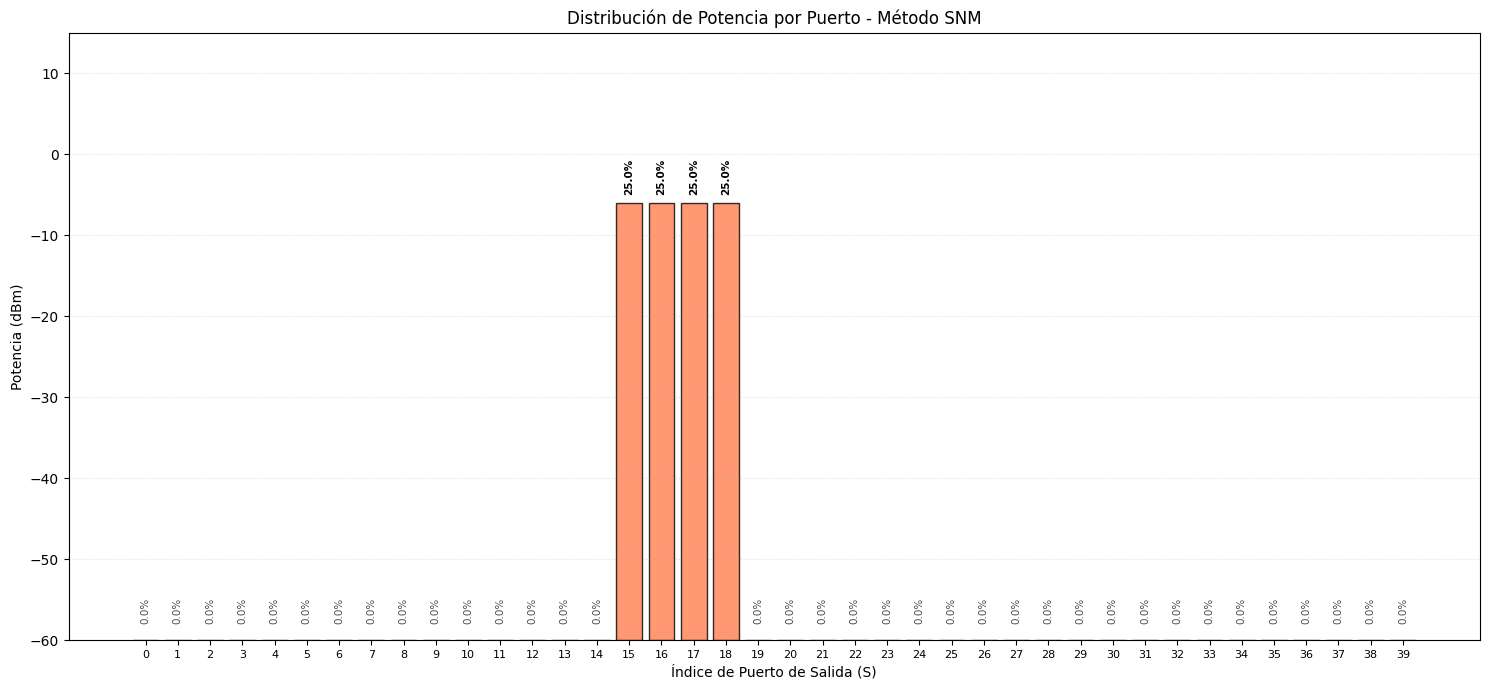

Balance Total: 100.00%


In [12]:
# Definición de la malla
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=True)

# Tu configuración semántica
configuracion = [
      (69, "x"),
    (68, "x"),
    (64, 0.5),
    (59, "x"),
    (58, "x"),
    (63, 0.5),
    (66, "x"),
    (67, "x"),
    (54, 0.5),
    (49, "x"),
    (45, "="),
    (40, "x"),
    (35, "="),
    (30, "x"),
    (26, "="),
    (21, "x"),
    (16, "x"),
    (10, "x"),
    (6, "x"),
    (0, "x"),
]

# Proceso completo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Inyección por el puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)

print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

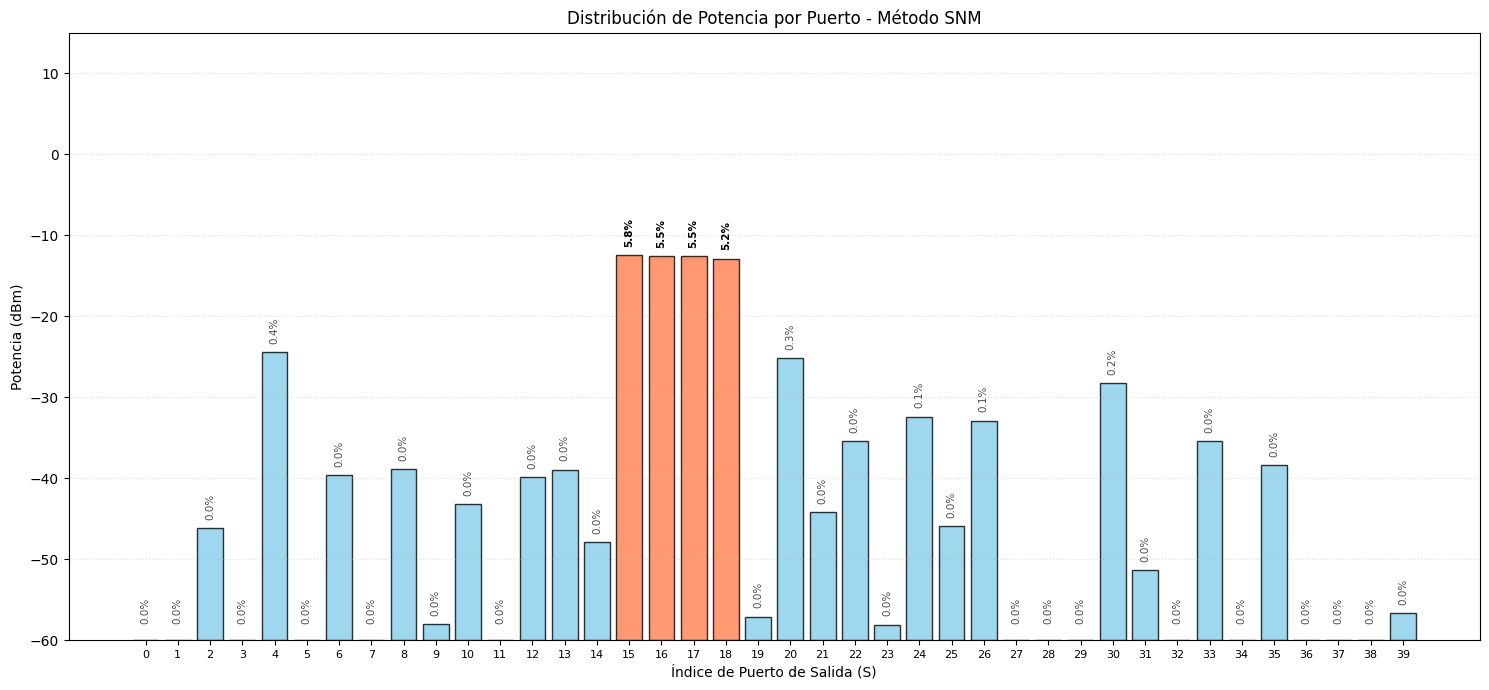

Balance Total: 23.01%


In [13]:
# Definición de la malla
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed = 42)

# Tu configuración semántica
configuracion = [
      (69, "x"),
    (68, "x"),
    (64, 0.5),
    (59, "x"),
    (58, "x"),
    (63, 0.5),
    (66, "x"),
    (67, "x"),
    (54, 0.5),
    (49, "x"),
    (45, "="),
    (40, "x"),
    (35, "="),
    (30, "x"),
    (26, "="),
    (21, "x"),
    (16, "x"),
    (10, "x"),
    (6, "x"),
    (0, "x"),
]

# Proceso completo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Inyección por el puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)

print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

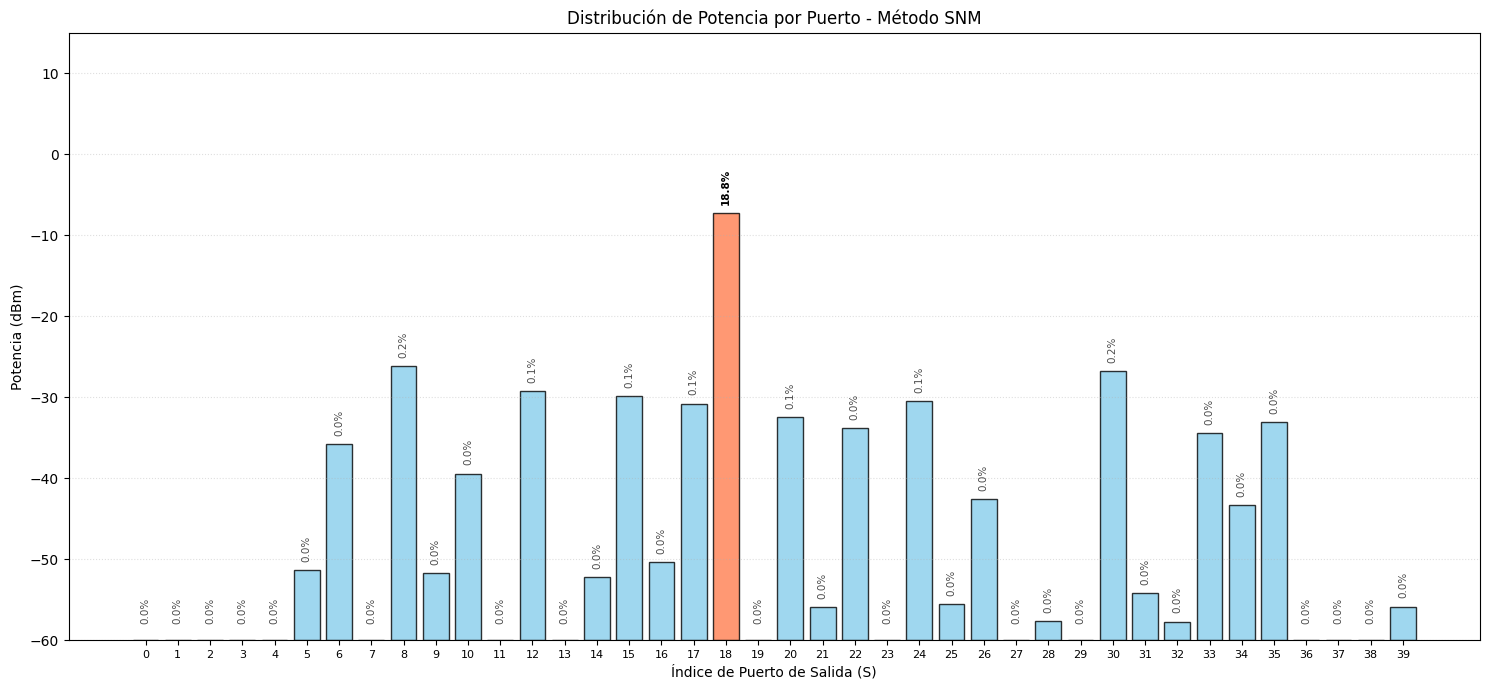

Balance Total: 19.85%


In [14]:
# Definición de la malla
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=False)

# Tu configuración semántica
configuracion = [
   (0, "x"),
    (6, "x"),
    (10, "x"),
    (16, "x"),
    (21, "x"),
    (26, "="),
    (30, "x"),
    (35, "="),
    (40, "x"),
    (45, "="),
    (49, "x"),
    (54, "="),
    (59, "x"),
    (64, "x"),
    (69, "x"),
]

# Proceso completo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Inyección por el puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)

print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

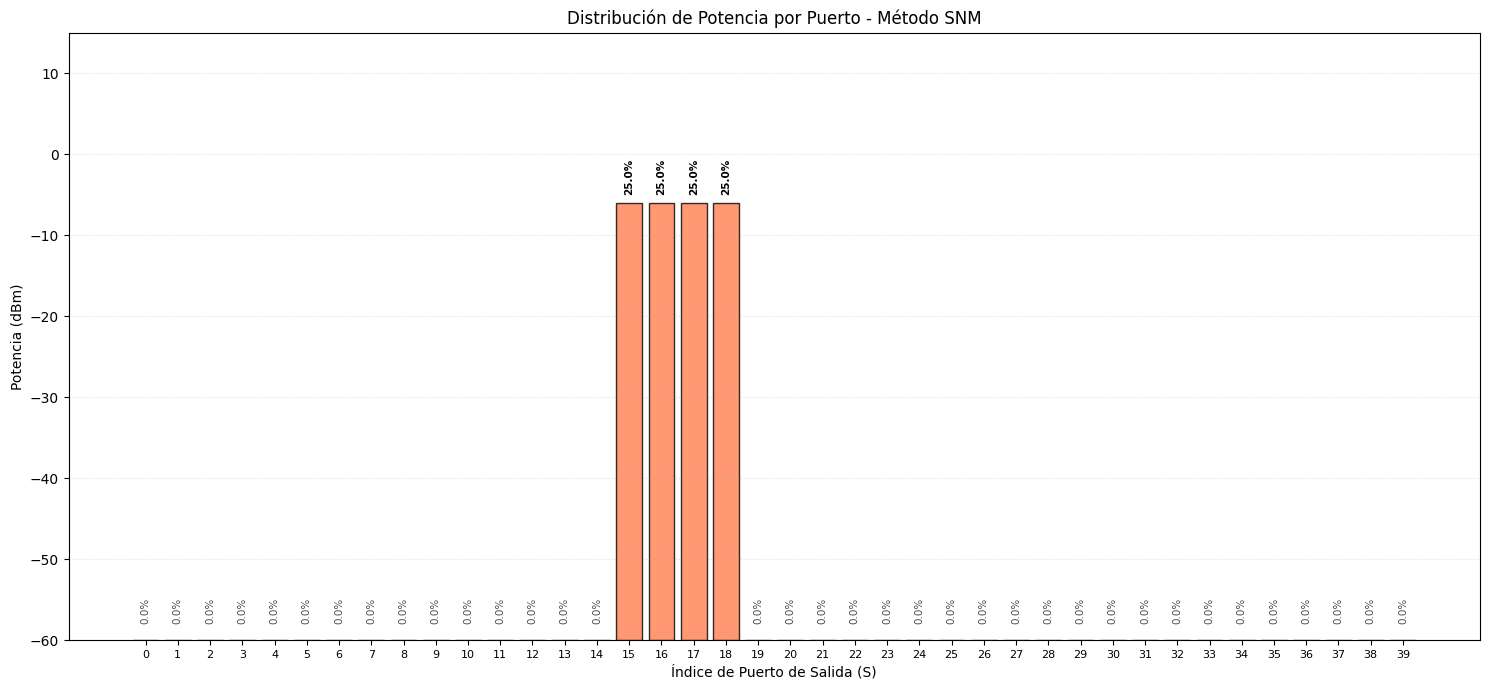

Balance Total: 100.00%


In [10]:
# Definición de la malla
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=True)

# Tu configuración semántica
configuracion = [
    (69, "x"),
    (68, "x"),
    (64, 0.5),
    (59, "x"),
    (58, "x"),
    (63, 0.5),
    (66, "x"),
    (67, "x"),
    (54, 0.5),
    (49, "x"),
    (45, "="),
    (40, "x"),
    (35, "="),
    (30, "x"),
    (26, "="),
    (21, "x"),
    (16, "x"),
    (10, "x"),
    (6, "x"),
    (0, "x"),
]

# Proceso completo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Inyección por el puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)

print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

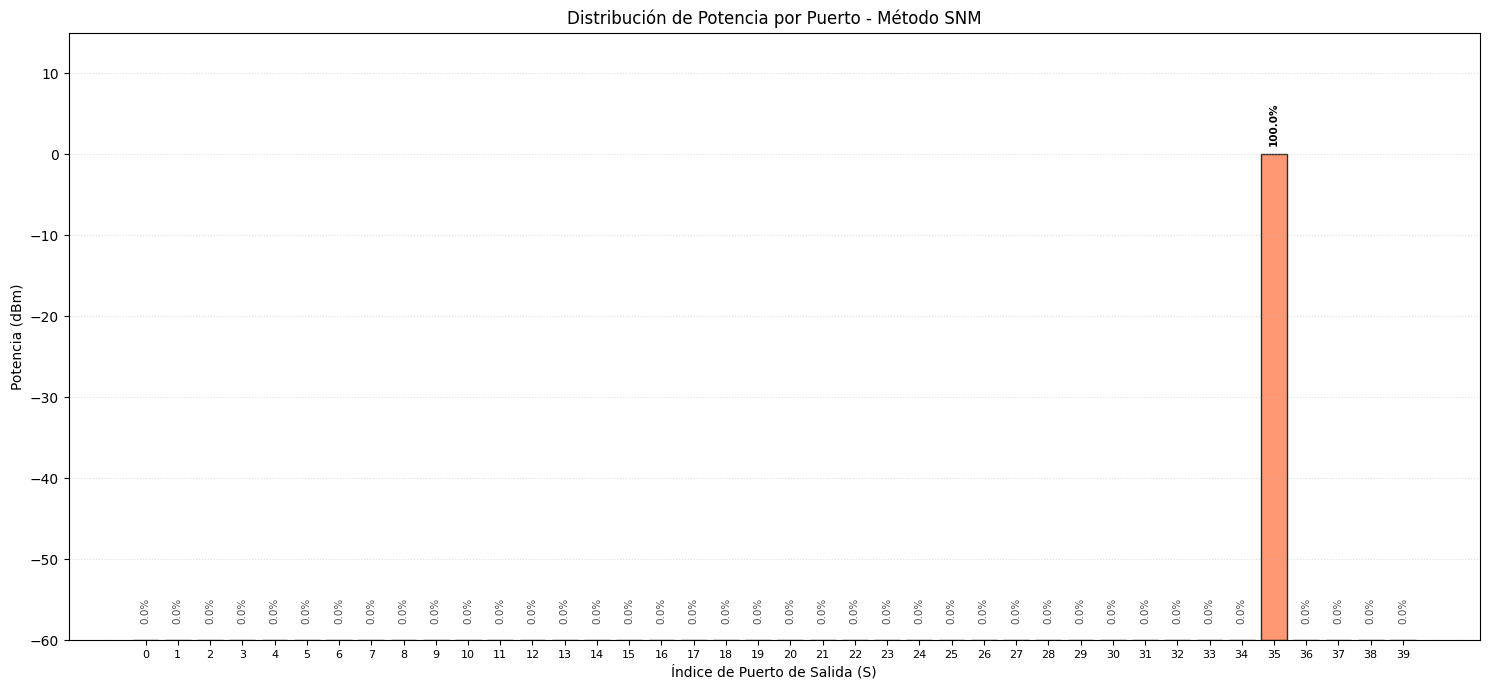

Balance Total: 100.00%


In [11]:
# Definición de la malla
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=True)

# Tu configuración semántica
configuracion = [
   (0, "="),
    (1, "x"),
    (2, 0.5),
    (3, "x"),
    (4, "x"),
    (5, 0.5),
    (7, "x"),
    (12, "="),
    (13, "="),
    (8, "x"),
]

# Proceso completo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Inyección por el puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)

print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

Ejecutando barrido espectral...


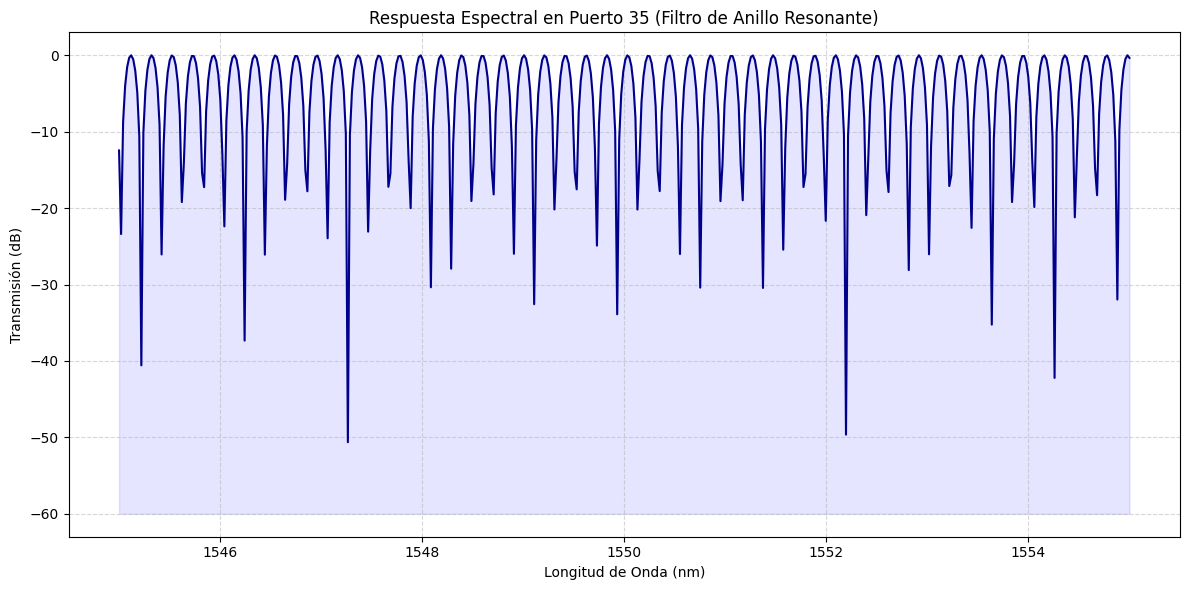

Barrido completado. Balance de energía promedio: -6.04 dB


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del barrido espectral
c_luz = 299792458  # Velocidad de la luz (m/s) [cite: 867]
lambda_nanometros = np.linspace(1545, 1555, 500)  # Rango de 1545 a 1555 nm [cite: 845]
longitudes_onda = lambda_nanometros * 1e-9
frecuencias_hz = c_luz / longitudes_onda
omegas = 2 * np.pi * frecuencias_hz  # Frecuencias angulares [cite: 862]

# Retardo base (tau) relacionado con la longitud física (BUL)
# Un valor de 1.5ps es típico para estas mallas [cite: 64, 59]
tau_base = 6.5e-12 

# 2. Configuración del diseño (Anillo resonante)
# Usamos tu configuración semántica que crea el bucle físico
config_anillo = [
    (0, "="),
    (1, "x"),
    (2, 0.5),
    (3, "x"),
    (4, "x"),
    (5, 0.5),
    (7, "x"),
    (12, "="),
    (13, "="),
    (8, "x"),
]

# Inicializamos la malla (ideal=False permite ver el efecto de los defectos en el filtro)
malla = malla_SNM_completa(tbus_columnas, ideal=True)
ids_40 = malla.obtener_ids_perimetrales_ordenados()

transmision_p35 = []

# 3. Bucle de simulación espectral [cite: 25, 36]
print("Ejecutando barrido espectral...")
for w in omegas:
    # Programamos la malla para cada frecuencia específica [cite: 210, 873]
    malla.programar_malla(config_anillo, omega=w, tau=tau_base)
    
    # Resolvemos la matriz de scattering total para esta frecuencia [cite: 188, 333]
    S_total = malla.resolver_matriz_total(ids_40)
    
    # Guardamos la potencia en el puerto 35 (inyectando por puerto 0) [cite: 24, 862]
    # S_total[índice_salida, índice_entrada]
    transmision_p35.append(np.abs(S_total[35, 0])**2)

# 4. Visualización de la respuesta del filtro (dB) [cite: 862]
potencia_db = 10 * np.log10(np.array(transmision_p35) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(lambda_nanometros, potencia_db, color='darkblue', linewidth=1.5)


plt.title("Respuesta Espectral en Puerto 35 (Filtro de Anillo Resonante)")
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Resaltar los valles de resonancia
plt.fill_between(lambda_nanometros, potencia_db, -60, color='blue', alpha=0.1)

plt.tight_layout()
plt.show()

# Verificación de estabilidad
print(f"Barrido completado. Balance de energía promedio: {np.mean(potencia_db):.2f} dB")

Ejecutando barrido espectral...


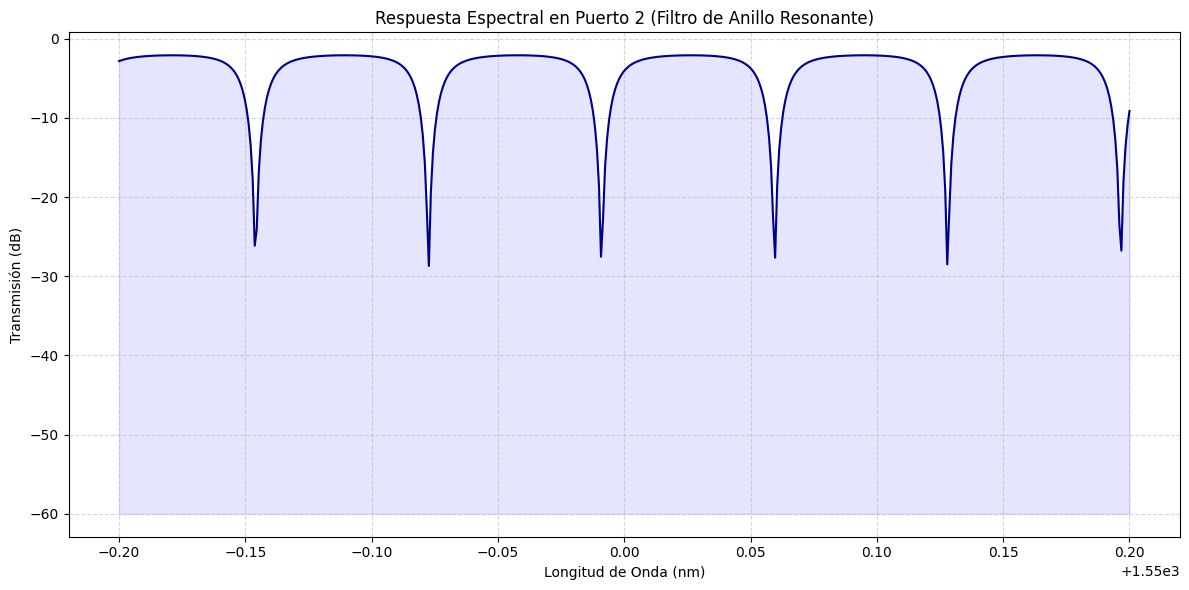

Barrido completado. Balance de energía promedio: -4.41 dB


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del barrido espectral
c_luz = 299792458  # Velocidad de la luz (m/s) [cite: 867]
lambda_nanometros = np.linspace(1549.8, 1550.2, 500)  # Rango de 1545 a 1555 nm [cite: 845]
longitudes_onda = lambda_nanometros * 1e-9
frecuencias_hz = c_luz / longitudes_onda
omegas = 2 * np.pi * frecuencias_hz  # Frecuencias angulares [cite: 862]

# Retardo base (tau) relacionado con la longitud física (BUL) de 811 micras
# Un valor de 1.5ps es típico para estas mallas [cite: 64, 59]
tau_base = 6.5e-12


# 2. Configuración del diseño (Anillo resonante)
# Usamos tu configuración semántica que crea el bucle físico
config_anillo = [
    (0, "x"), (6, 0.5), (10, "="),(11, "="),(7, "="),(2, "="),(1, "="),(9, "=")
]

# Inicializamos la malla (ideal=False permite ver el efecto de los defectos en el filtro)
malla = malla_SNM_completa(tbus_columnas, ideal=False)
ids_40 = malla.obtener_ids_perimetrales_ordenados()

transmision_p35 = []

# 3. Bucle de simulación espectral [cite: 25, 36]
print("Ejecutando barrido espectral...")
for w in omegas:
    # Programamos la malla para cada frecuencia específica [cite: 210, 873]
    malla.programar_malla(config_anillo, omega=w, tau=tau_base)
    
    # Resolvemos la matriz de scattering total para esta frecuencia [cite: 188, 333]
    S_total = malla.resolver_matriz_total(ids_40)
    
    # Guardamos la potencia en el puerto 35 (inyectando por puerto 0) [cite: 24, 862]
    # S_total[índice_salida, índice_entrada]
    transmision_p35.append(np.abs(S_total[2, 0])**2)

# 4. Visualización de la respuesta del filtro (dB) [cite: 862]
potencia_db = 10 * np.log10(np.array(transmision_p35) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(lambda_nanometros, potencia_db, color='darkblue', linewidth=1.5)


plt.title("Respuesta Espectral en Puerto 2 (Filtro de Anillo Resonante)")
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Resaltar los valles de resonancia
plt.fill_between(lambda_nanometros, potencia_db, -60, color='blue', alpha=0.1)

plt.tight_layout()
plt.show()

# Verificación de estabilidad
print(f"Barrido completado. Balance de energía promedio: {np.mean(potencia_db):.2f} dB")

Ejecutando barrido espectral...


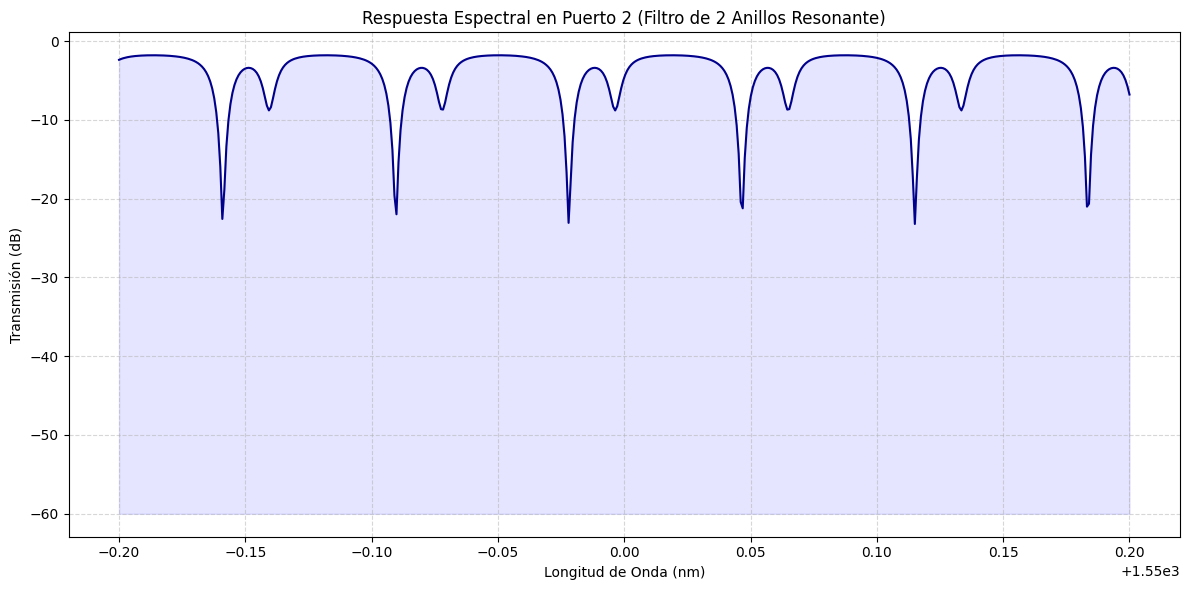

Barrido completado. Balance de energía promedio: -4.30 dB


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del barrido espectral
c_luz = 299792458  # Velocidad de la luz (m/s) [cite: 867]
lambda_nanometros = np.linspace(1549.8, 1550.2, 500)  # Rango de 1545 a 1555 nm [cite: 845]
longitudes_onda = lambda_nanometros * 1e-9
frecuencias_hz = c_luz / longitudes_onda
omegas = 2 * np.pi * frecuencias_hz  # Frecuencias angulares [cite: 862]

# Retardo base (tau) relacionado con la longitud física (BUL) de 811 micras
# Un valor de 1.5ps es típico para estas mallas [cite: 64, 59]
tau_base = 6.5e-12


# 2. Configuración del diseño (Anillo resonante)
# Usamos tu configuración semántica que crea el bucle físico
config_anillo = [
    (0, "x"), (6, 0.5), (10, "="),(11, "="),(7, 0.5),(2, "="),(1, "="),(9, "="), (12, "="), (13, "="), (8, "="), (4, "="), (3, "=")
]

# Inicializamos la malla (ideal=False permite ver el efecto de los defectos en el filtro)
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed = 42)
ids_40 = malla.obtener_ids_perimetrales_ordenados()

transmision_p35 = []

# 3. Bucle de simulación espectral [cite: 25, 36]
print("Ejecutando barrido espectral...")
for w in omegas:
    # Programamos la malla para cada frecuencia específica [cite: 210, 873]
    malla.programar_malla(config_anillo, omega=w, tau=tau_base)
    
    # Resolvemos la matriz de scattering total para esta frecuencia [cite: 188, 333]
    S_total = malla.resolver_matriz_total(ids_40)
    
    # Guardamos la potencia en el puerto 35 (inyectando por puerto 0) [cite: 24, 862]
    # S_total[índice_salida, índice_entrada]
    transmision_p35.append(np.abs(S_total[2, 0])**2)

# 4. Visualización de la respuesta del filtro (dB) [cite: 862]
potencia_db = 10 * np.log10(np.array(transmision_p35) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(lambda_nanometros, potencia_db, color='darkblue', linewidth=1.5)


plt.title("Respuesta Espectral en Puerto 2 (Filtro de 2 Anillos Resonante)")
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Resaltar los valles de resonancia
plt.fill_between(lambda_nanometros, potencia_db, -60, color='blue', alpha=0.1)

plt.tight_layout()
plt.show()

# Verificación de estabilidad
print(f"Barrido completado. Balance de energía promedio: {np.mean(potencia_db):.2f} dB")

Ejecutando barrido espectral...


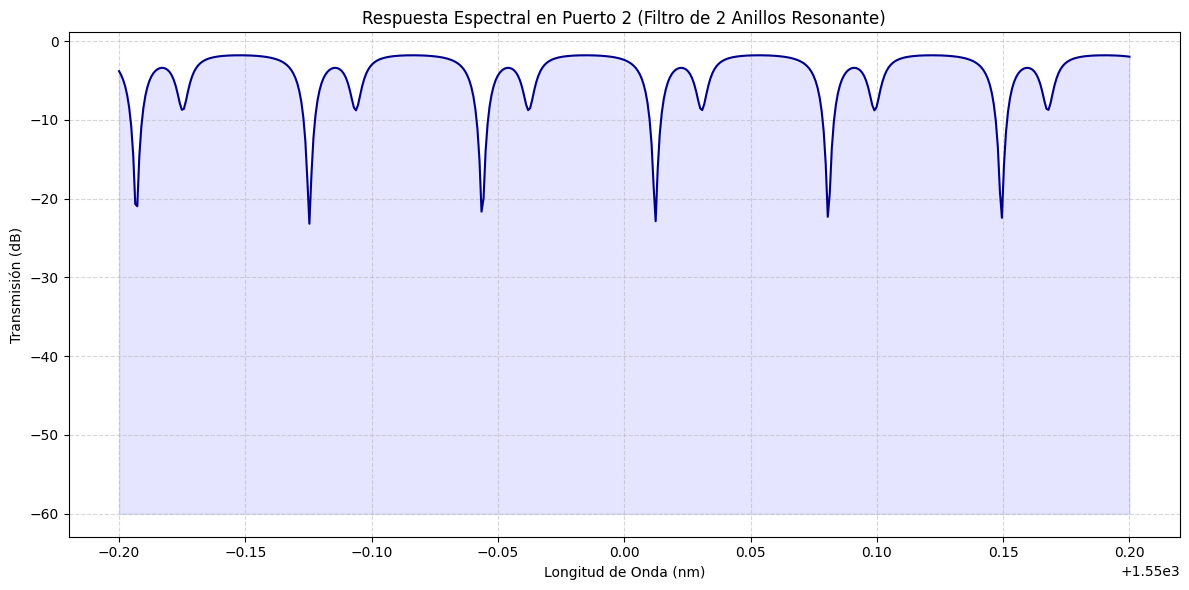

Barrido completado. Balance de energía promedio: -4.36 dB


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del barrido espectral
c_luz = 299792458  # Velocidad de la luz (m/s) [cite: 867]
lambda_nanometros = np.linspace(1549.8, 1550.2, 500)  # Rango de 1545 a 1555 nm [cite: 845]
longitudes_onda = lambda_nanometros * 1e-9
frecuencias_hz = c_luz / longitudes_onda
omegas = 2 * np.pi * frecuencias_hz  # Frecuencias angulares [cite: 862]

# Retardo base (tau) relacionado con la longitud física (BUL) de 811 micras
# Un valor de 1.5ps es típico para estas mallas [cite: 64, 59]
tau_base = 6.5e-12
fase_comun_prueba = np.pi / 2

# 2. Configuración del diseño (Anillo resonante)
# Usamos tu configuración semántica que crea el bucle físico
config_anillo = [
    (0, "x"), (6, 0.5), (10, "="),(11, "="),(7, 0.5),(2, "="),(1, "="),(9, "="), (12, "="), (13, "="), (8, "="), (4, "="), (3, "=")
]

# Inicializamos la malla (ideal=False permite ver el efecto de los defectos en el filtro)
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed = 42)
ids_40 = malla.obtener_ids_perimetrales_ordenados()

transmision_p35 = []

# 3. Bucle de simulación espectral [cite: 25, 36]
print("Ejecutando barrido espectral...")
for w in omegas:
    # Programamos la malla para cada frecuencia específica [cite: 210, 873]
    malla.programar_malla(config_anillo, omega=w, tau=tau_base, fase_comun = fase_comun_prueba)
    
    # Resolvemos la matriz de scattering total para esta frecuencia [cite: 188, 333]
    S_total = malla.resolver_matriz_total(ids_40)
    
    # Guardamos la potencia en el puerto 35 (inyectando por puerto 0) [cite: 24, 862]
    # S_total[índice_salida, índice_entrada]
    transmision_p35.append(np.abs(S_total[2, 0])**2)

# 4. Visualización de la respuesta del filtro (dB) [cite: 862]
potencia_db = 10 * np.log10(np.array(transmision_p35) + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(lambda_nanometros, potencia_db, color='darkblue', linewidth=1.5)


plt.title("Respuesta Espectral en Puerto 2 (Filtro de 2 Anillos Resonante)")
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Resaltar los valles de resonancia
plt.fill_between(lambda_nanometros, potencia_db, -60, color='blue', alpha=0.1)

plt.tight_layout()
plt.show()

# Verificación de estabilidad
print(f"Barrido completado. Balance de energía promedio: {np.mean(potencia_db):.2f} dB")

Simulando fase común: 0.00π ...
Simulando fase común: 0.25π ...
Simulando fase común: 0.50π ...
Simulando fase común: 1.00π ...


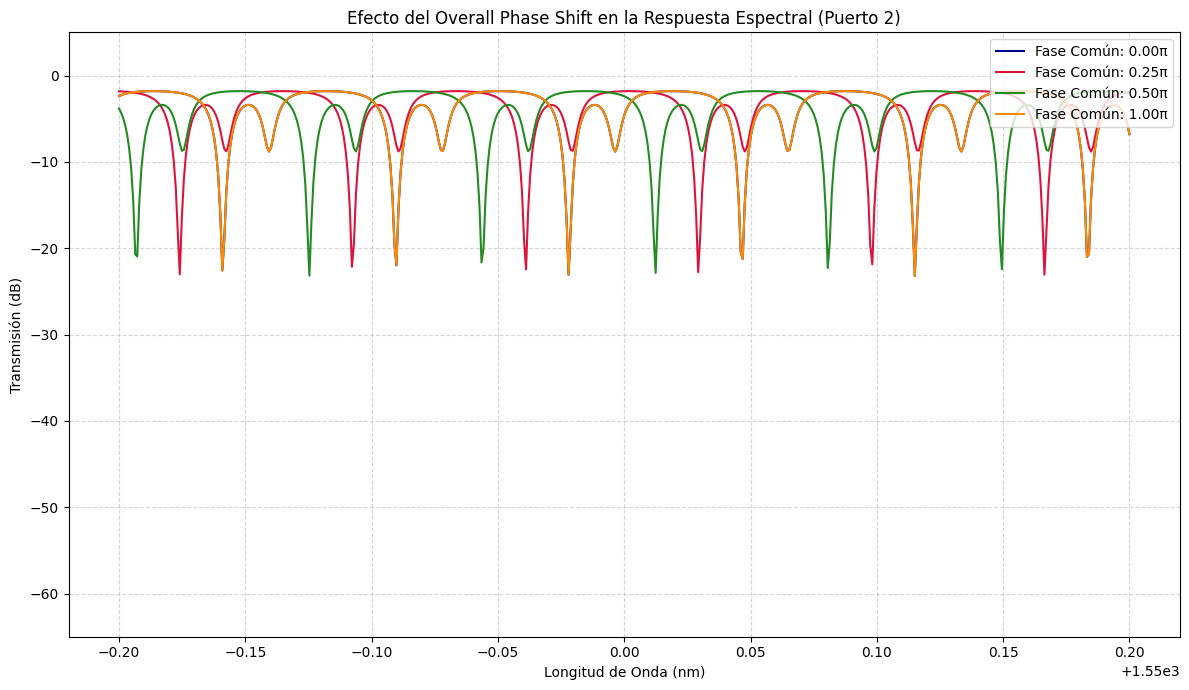

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del barrido espectral
c_luz = 299792458
lambda_nanometros = np.linspace(1549.8, 1550.2, 500)
longitudes_onda = lambda_nanometros * 1e-9
omegas = 2 * np.pi * (c_luz / longitudes_onda)

tau_base = 6.5e-12

# --- DEFINICIÓN DE LAS FASES A PROBAR ---
# Vamos a probar con 0, pi/4, pi/2 y pi
fases_a_probar = [0, np.pi/4, np.pi/2, np.pi]
colores = ['darkblue', 'crimson', 'forestgreen', 'darkorange']

# 2. Configuración del diseño
config_anillo = [
    (0, "x"), (6, 0.5), (10, "="), (11, "="), (7, 0.5), (2, "="), 
    (1, "="), (9, "="), (12, "="), (13, "="), (8, "="), (4, "="), (3, "=")
]

malla = malla_SNM_completa(tbus_columnas, ideal=False, seed=42)
ids_40 = malla.obtener_ids_perimetrales_ordenados()

plt.figure(figsize=(12, 7))

# 3. Doble bucle: Fases de prueba y Frecuencias
for fase, color in zip(fases_a_probar, colores):
    transmision_p2 = []
    print(f"Simulando fase común: {fase/np.pi:.2f}π ...")
    
    for w in omegas:
        # Programamos con la fase común actual
        malla.programar_malla(config_anillo, omega=w, tau=tau_base, fase_comun=fase)
        S_total = malla.resolver_matriz_total(ids_40)
        # Inyectamos por 0, medimos en 2
        transmision_p2.append(np.abs(S_total[2, 0])**2)
    
    # 4. Añadimos la curva a la gráfica
    potencia_db = 10 * np.log10(np.array(transmision_p2) + 1e-12)
    plt.plot(lambda_nanometros, potencia_db, color=color, linewidth=1.5, 
             label=f"Fase Común: {fase/np.pi:.2f}π")

# Configuración final de la gráfica
plt.title("Efecto del Overall Phase Shift en la Respuesta Espectral (Puerto 2)")
plt.xlabel("Longitud de Onda (nm)")
plt.ylabel("Transmisión (dB)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.ylim([-65, 5]) # Ajustamos el eje Y para ver bien los valles

plt.tight_layout()
plt.show()

In [20]:
def aplicar_ruido_termico(potencias_opticas, bandwidth_hz=10e9):
    """
    Añade ruido térmico basado en la constante de -174 dBm/Hz.
    bandwidth_hz: El ancho de banda del detector (ej. 10GHz).
    """
    # 1. Calculamos la potencia de ruido en dBm
    # Ruido_total = -174 + 10*log10(Ancho_de_Banda)
    p_ruido_dbm = -174 + 10 * np.log10(bandwidth_hz)
    
    # 2. Pasamos de dBm a Watts reales
    p_ruido_watts = 10**((p_ruido_dbm - 30) / 10)
    
    # 3. Generamos el ruido gausiano
    # La potencia de ruido calculada es la varianza (sigma^2)
    sigma = np.sqrt(p_ruido_watts)
    ruido = np.random.normal(0, sigma, size=potencias_opticas.shape)
    
    # 4. Sumamos a la señal
    return np.maximum(potencias_opticas + ruido, 1e-18)

In [28]:
# 1. Definición de la malla y configuración (igual que antes)
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed=42)

configuracion = [
    (0, "="), (1, "x"), (2, 0.5), (3, "x"), (4, "x"),
    (5, 0.5), (7, "x"), (12, "="), (13, "="), (8, "x"),
]

# 2. Proceso completo de cálculo
malla.programar_malla(configuracion)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# 3. Inyección de potencia (Referencia 1mW para que 1.0 lineal = 0 dBm)
potencia_entrada_watts = 1e-3 
potencias_lineales = np.abs(S_total[:, 0])**2 * potencia_entrada_watts

# 4. Aplicar el ruido térmico en LINEAL (IMPORTANTE: el ruido se suma en vatios)
# Usamos la función de los -174 dBm/Hz que definimos
potencias_con_ruido_watts = aplicar_ruido_termico(potencias_lineales, band_hz=10e9)

# 5. Convertir a dBm AQUÍ (fuera de la función de graficar)
# Sumamos 1e-15 para evitar el log(0) si no hubiera ruido
potencias_dbm = 10 * np.log10(potencias_con_ruido_watts / 1e-3 + 1e-15)

# 6. Resultado visual
# Como tu función ya espera dBm, le pasamos el array 'potencias_dbm' directamente
graficar_salida_dbm(potencias_dbm, ids_40)

print(f"Balance Total: {np.sum(np.abs(S_total[:, 0])**2)*100:.2f}%")

TypeError: aplicar_ruido_termico() got an unexpected keyword argument 'bw_hz'